# Getting Started with Modeling in Python

This notebook provides a practical, hands-on application of the concepts discuessed in Week 1. We will walk through the essential steps of a basic modeling workflow: loading data, performing exploratory data analysis (EDA), fitting a model, and interpreting its results.

---

## 1. Import Libraries and Load Data
First, we import the necessary libraries for data manipulation, visualization, and statistical modeling. We will use the standard "diabetes" dataset available in scikit-learn, which is pre-cleaned and scaled, making it ideal for an introductory exercise.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.datasets import load_diabetes

# Load the dataset
diabetes_dataset = load_diabetes()

# Create a Pandas dataframe for easier manipulation 
# The main data is in .data and feature names are in .feature_names
df = pd.DataFrame(data=diabetes_dataset.data, columns=diabetes_dataset.feature_names)

# The target variable (a quantitative measure of disease progression) is separate
df['progression'] = diabetes_dataset.target


---

## 2. Initial Data Exploration
Before modeling, it's crucial to understand the structure and contents of our dataset.

In [10]:
# Check the dimensions of the dataset (rows, columns)
print("Dataset shape:", df.shape)
print("="*50)

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("="*50)

# Display the first few rows to get a feel for the data
print("First 5 rows of the dataset:")
df.head()

Dataset shape: (442, 11)
Missing values per column:
age            0
sex            0
bmi            0
bp             0
s1             0
s2             0
s3             0
s4             0
s5             0
s6             0
progression    0
dtype: int64
First 5 rows of the dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


The dataset is clean and ready for analysis. Our **dependent variable** will be `progression`, and the other 10 columns will serve as potential **independent variables**.

---

## 3. Exploratory Data Analysis (EDA)
Before building a multiple regression model, it's helpful to visualize the relationships between our variables.

### Correlation Matrix
A heatmap of the correlation matrix gives us a quick overview of how all variables relate to each other. This is useful for identifying which predictors are most strongly correlated with our outcome and for spotting potential multicollinearity (strong correlations between predictors).

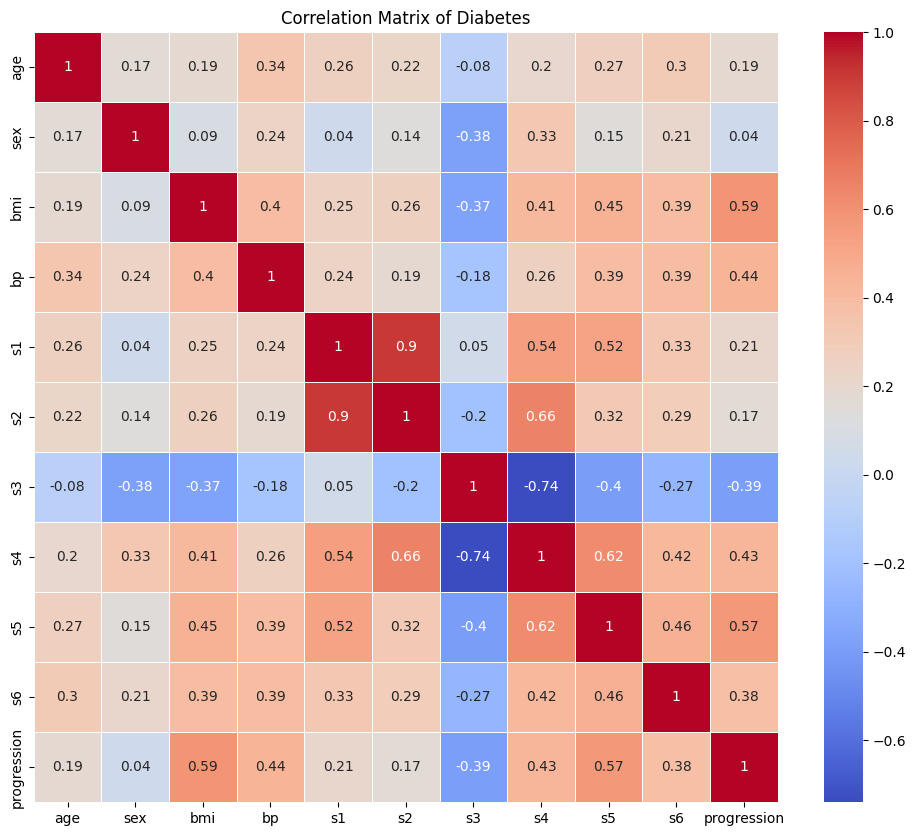

In [11]:
# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Calculate the correlation matrix
correlation_matrix = df.corr().round(2)

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=.5)
plt.title("Correlation Matrix of Diabetes")
plt.show()

From the heatmap, we can see that `bmi`, `s5` (a measure of triglycerides), and `bp` have the strongest positive correlations with our outcome, `progression`. We also note strong correlations between some predictors, like `s1` and `s2`.

### Bivariate Scatterplots
Let's create scatterplots for a few key indicators against our outcome variable. This helps us visually assess the form, direction, and strength of each relationship. We'll add a `lowess` (locally weighted scatterplot smoothing) line to help see the pattern.